In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


In [91]:
df = pd.read_csv(
    r"D:/End-to-end-ML/SpamClassifier/Data/spam.csv",
    encoding='latin-1'
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [92]:
df = df.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"],axis=1)

In [93]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [94]:
df = df.rename(columns={"v1":"Target","v2":"Texts"})

In [95]:
df

,Target,Texts
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [96]:
df["Target"] = df["Target"].map({"ham":0 , "spam" : 1})

In [97]:
df

,Target,Texts
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Target  5572 non-null   int64 
 1   Texts   5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [99]:
df.duplicated().sum()

403

In [100]:
df = df.drop_duplicates(keep='first')

In [101]:
df.shape


(5169, 2)

In [102]:
df["Target"].value_counts(normalize=True)*100

Target
0    87.366996
1    12.633004
Name: proportion, dtype: float64

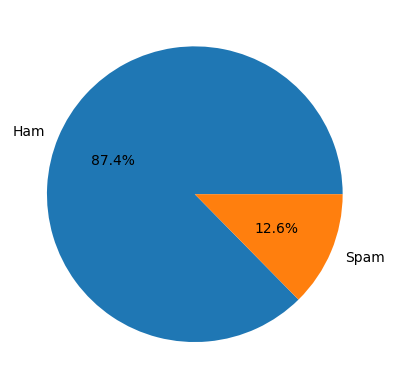

In [103]:
plt.pie(
    df["Target"].value_counts(),
    labels=["Ham", "Spam"],
    autopct='%1.1f%%'
);

### EDA and Feature Engineering

In [104]:
df.value_counts()

Target  Texts                                                                                                                             
0        &lt;#&gt;  in mca. But not conform.                                                                                                  1
        Thats cool. i liked your photos. You are very sexy!                                                                                   1
        That's good, because I need drugs                                                                                                     1
        That's fine, have him give me a call if he knows what he wants or has any questions                                                   1
        That's fine, I'll bitch at you about it later then                                                                                    1
                                                                                                                                             

In [105]:
df["char_num"] = df["Texts"].apply(len)

C:\Users\HP\AppData\Local\Temp\ipykernel_6040\235870981.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["char_num"] = df["Texts"].apply(len)


In [106]:
df

,Target,Texts,char_num
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [107]:
nlp = spacy.load('en_core_web_sm')

In [108]:
df["token_len"] = df["Texts"].apply(lambda x: len([token.text for token in nlp(x)]))

C:\Users\HP\AppData\Local\Temp\ipykernel_6040\963582159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["token_len"] = df["Texts"].apply(lambda x: len([token.text for token in nlp(x)]))


In [109]:
df

,Target,Texts,char_num,token_len
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,31
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,39
5568,0,Will Ì_ b going to esplanade fr home?,37,10
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [110]:
df["sent_len"] = df["Texts"].apply(lambda x: len(list(nlp(x).sents)))

C:\Users\HP\AppData\Local\Temp\ipykernel_6040\2582287242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sent_len"] = df["Texts"].apply(lambda x: len(list(nlp(x).sents)))


In [111]:
df

,Target,Texts,char_num,token_len,sent_len
0,0,"Go until jurong point, crazy.. Available only ...",111,24,3
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,31,3
3,0,U dun say so early hor... U c already then say...,49,13,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,39,4
5568,0,Will Ì_ b going to esplanade fr home?,37,10,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [112]:
df1 = df.drop("Texts",axis=1)
corr = df1.corr()

In [113]:
corr

,Target,char_num,token_len,sent_len
Target,1.000000,0.384717,0.283608,0.248813
char_num,0.384717,1.000000,0.973170,0.687399
token_len,0.283608,0.973170,1.000000,0.731212
sent_len,0.248813,0.687399,0.731212,1.000000


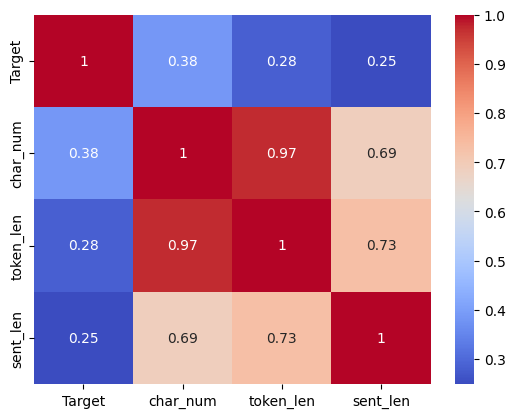

In [114]:
sns.heatmap(corr, cmap='coolwarm', annot=True);

In [115]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
Target,5169.0,0.126330,0.332253,0.0,0.0,0.0,0.0,1.0
char_num,5169.0,78.977945,58.236293,2.0,36.0,60.0,117.0,910.0
token_len,5169.0,18.339911,13.175170,1.0,9.0,15.0,26.0,196.0
sent_len,5169.0,2.122848,1.481111,1.0,1.0,2.0,3.0,31.0


In [116]:
#HAM Description
df1[df1["Target"]==0].describe().T

,count,mean,std,min,25%,50%,75%,max
Target,4516.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
char_num,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
token_len,4516.0,16.919176,13.224373,1.0,8.0,13.0,22.0,196.0
sent_len,4516.0,1.982728,1.431233,1.0,1.0,2.0,2.0,31.0


In [117]:
#SPAM Description
df1[df1["Target"]==1].describe().T

,count,mean,std,min,25%,50%,75%,max
Target,653.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
char_num,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0
token_len,653.0,28.165391,7.361204,2.0,25.0,29.0,33.0,49.0
sent_len,653.0,3.091884,1.458257,1.0,2.0,3.0,4.0,8.0


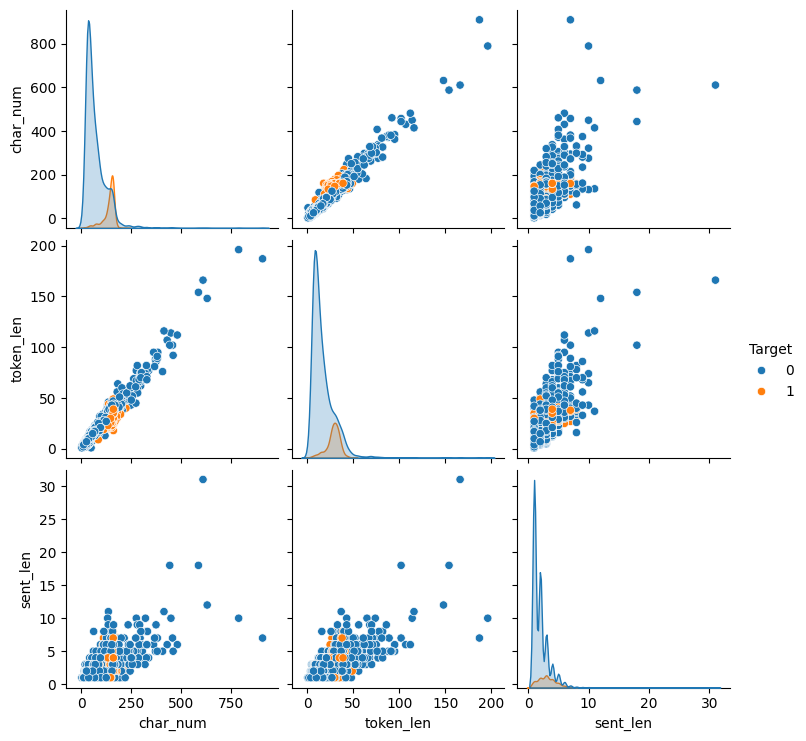

In [118]:
sns.pairplot(df, hue = 'Target');

### Data Preprocessing

In [119]:
nlp = spacy.load("en_core_web_sm")

In [120]:
def preprocess_text(text):

    doc = nlp(text)

    tokens = []

    for token in doc:

        # Remove stopwords + punctuation + spaces
        if token.is_stop or token.is_punct or token.is_space:
            continue

        # Keep alphanumeric words only
        if not token.text.isalnum():
            continue

        # Lemmatization + lowercase
        tokens.append(token.lemma_.lower())

    return " ".join(tokens)

In [121]:
df["transformed_texts"] = df["Texts"].apply(preprocess_text)

C:\Users\HP\AppData\Local\Temp\ipykernel_6040\2371988678.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["transformed_texts"] = df["Texts"].apply(preprocess_text)


In [122]:
df

,Target,Texts,char_num,token_len,sent_len,transformed_texts
0,0,"Go until jurong point, crazy.. Available only ...",111,24,3,jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,31,3,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,2,u dun early hor u c
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think go usf live
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,39,4,2nd time try 2 contact u win pound prize 2 cla...
5568,0,Will Ì_ b going to esplanade fr home?,37,10,1,ì b go esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,pity mood suggestion
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitching act like interested buy week give...


In [123]:
spam_corpus = []
for msg in df[df["Target"]==1]["transformed_texts"].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [124]:
len(spam_corpus)

9598

In [125]:
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,free,194
1,2,156
2,txt,136
3,text,124
4,ur,119
5,mobile,115
6,u,113
7,stop,104
8,reply,100
9,4,99


In [126]:
ham_corpus = []
for msg in df[df["Target"]==0]["transformed_texts"].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [127]:
len(ham_corpus)

30886

In [128]:
pd.DataFrame(Counter(ham_corpus).most_common(30))

,0,1
0,u,863
1,go,307
2,come,296
3,2,292
4,get,275
5,not,275
6,ok,249
7,know,246
8,good,239
9,like,230


### Model Training.

In [131]:
tfidf = TfidfVectorizer()

In [132]:
X = tfidf.fit_transform(df['transformed_texts']).toarray()

In [133]:
X.shape

(5169, 7044)

In [134]:
y = df['Target'].values

In [136]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)